In [1]:
import pandas as pd
from src.preprocessing import handle_missing_values
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
TARGET_COLUMN_2 = "war_class"
TARGET = "war_class"
dev_path_2 = "data/Problem_2/raw/WAR_class_dev.csv"
test_path_2 = "data/Problem_2/raw/WAR_class_test.csv"

WAR_class_dev_df = pd.read_csv(dev_path_2, na_values=["NaN", "N/A", ""])
WAR_class_dev_df = WAR_class_dev_df.drop(columns=['war_total'])
WAR_class_test_df = pd.read_csv(test_path_2, na_values=["NaN", "N/A", ""])
WAR_class_test_df = WAR_class_test_df.drop(columns=['war_total'])

In [3]:
new_ranges_2 = {
    # 'poss': (-448.59, 9329.40),
    # 'mp': (-235.33, 4264.46),
    'raptor_total': (-17.5, 15), # cambio
    # 'war_total': (-7.38, 28.76),
    'pace_impact': (-2, 3.5), # cambio
}

WAR_class_dev = handle_missing_values(
    data=WAR_class_dev_df, 
    target_col=TARGET_COLUMN_2,
    train=True,
    intervals=new_ranges_2,
)


In [4]:
from src.models import LogisticRegression

from src.preprocessing import normalize_dataframe
from src.data_splitting import split_train_validation
from src.preprocessing import calculate_stats_dict
from metrics2 import accuracy, precision, recall, f1_score, plot_roc_curve, plot_pr_curve, auc, plot_conf_matrix

In [5]:
RANDOM_STATE = 42

WAR_class_train_df, WAR_class_val_df = split_train_validation(WAR_class_dev, val_ratio=0.2, seed=RANDOM_STATE)

WAR_class_normalized_train, WAR_class_dev_train_stats = normalize_dataframe(WAR_class_train_df, train=True, target_col=TARGET_COLUMN_2)
WAR_class_normalized_val, _ = normalize_dataframe(WAR_class_val_df, train=False, stats_dict=WAR_class_dev_train_stats, target_col=TARGET_COLUMN_2)


# trv - train-validation
Wc_X_train_trv = WAR_class_normalized_train.drop(columns=[TARGET_COLUMN_2]).values
Wc_y_train_trv = WAR_class_normalized_train[TARGET_COLUMN_2].values
Wc_X_val_trv = WAR_class_normalized_val.drop(columns=[TARGET_COLUMN_2]).values
Wc_y_val_trv = WAR_class_normalized_val[TARGET_COLUMN_2].values



In [6]:
# split the data into train and validation sets

WAR_class_dev = handle_missing_values(
    data=WAR_class_dev_df, 
    target_col=TARGET_COLUMN_2,
    train=True,
    intervals=new_ranges_2,
)

# data, target_col, train=True, reference=None, intervals=None, stats_dict=None, neighbors=5
WAR_class_train, WAR_class_val = split_train_validation(WAR_class_dev, seed=RANDOM_STATE)
WAR_class_train_cleaned = handle_missing_values(
    data=WAR_class_train, 
    target_col=TARGET_COLUMN_2, 
    train=True,
    intervals=new_ranges_2
)

WAR_class_train_cleaned_normalized, normalized_train_stats = normalize_dataframe(WAR_class_train_cleaned)

train_stats = calculate_stats_dict(WAR_class_train_cleaned)

WAR_class_val_cleaned = handle_missing_values(
    data=WAR_class_val, 
    target_col=TARGET_COLUMN_2, 
    train=False, 
    reference=WAR_class_train_cleaned,
    intervals=new_ranges_2, 
    stats_dict=train_stats 
)
WAR_class_val_cleaned_normalized, _ = normalize_dataframe(WAR_class_val_cleaned, train=False, stats_dict=normalized_train_stats)

In [7]:
X_train = WAR_class_train_cleaned_normalized.drop(columns=[TARGET])
y_train = WAR_class_train_cleaned_normalized[TARGET]

X_val = WAR_class_val_cleaned_normalized.drop(columns=[TARGET])
y_val = WAR_class_val_cleaned_normalized[TARGET]

In [8]:
from src.models import LDA, RandomForest

In [9]:
# # train with logistic regression
# log_reg = LogisticRegression(multiclass_strategy='multinomial')

# # Definir rango de lambda
# lambdas = np.logspace(0, 4, 100)
# f1_scores = []

# best_f1 = -1
# best_model = None
# best_lambda = None

# for l2 in lambdas:
#     log_reg = LogisticRegression(multiclass_strategy='multinomial', l2=l2)
#     log_reg.fit(X_train, y_train)

#     y_val_pred_lr_lambdas = log_reg.predict(X_val)
#     f1 = f1_score(y_val, y_val_pred_lr_lambdas)
#     f1_scores.append(f1)

#     if f1 > best_f1:
#         best_f1 = f1
#         best_lambda = l2
#         best_model = log_reg

# # Graficar F1 Score vs Lambda
# plt.figure()
# plt.plot(lambdas, f1_scores)
# plt.scatter(best_lambda, best_f1, color='red', label='Mejor Lambda')
# plt.xscale('log')
# plt.xlabel("Lambda (Regularización L2)")
# plt.ylabel("F1 Score (Macro)")
# plt.title("Selección de Lambda usando F1 Score (Validación)")
# plt.legend()
# plt.grid(True)
# plt.show()

# print(f"Mejor modelo encontrado con λ = {best_lambda:.5f} (F1 Score = {best_f1:.4f})")

# # Evaluar mejor modelo
# y_val_pred_lr = best_model.predict(X_val)
# y_val_pred_proba_lr = best_model.predict_proba(X_val)





In [10]:
# accuracy_score = accuracy(y_val, y_val_pred_lr)
# precision_score = precision(y_val, y_val_pred_lr)
# recall_score = recall(y_val, y_val_pred_lr)
# f1_score_value = f1_score(y_val, y_val_pred_lr)

# print(f"Accuracy: {accuracy_score:.4f}")
# print(f"Precision: {precision_score:.4f}")
# print(f"Recall: {recall_score:.4f}")
# print(f"F1 Score: {f1_score_value:.4f}")

# plot_conf_matrix(y_val, y_val_pred_lr)
# _ = plot_pr_curve(y_val, y_val_pred_proba_lr)
# _ = plot_roc_curve(y_val, y_val_pred_proba_lr)

Accuracy: 0.9307
Precision: 0.9328
Recall: 0.9380
F1 Score: 0.9310


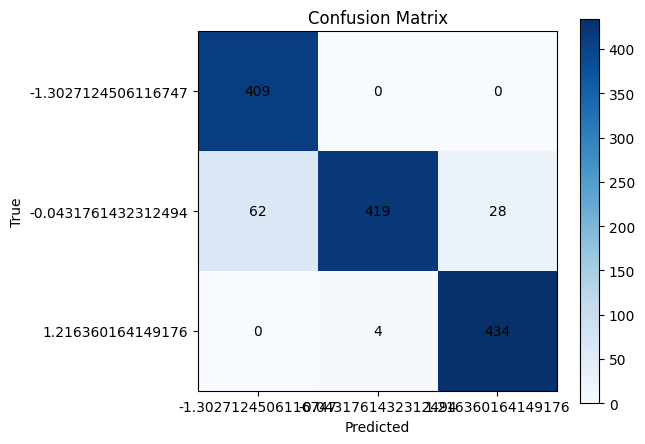

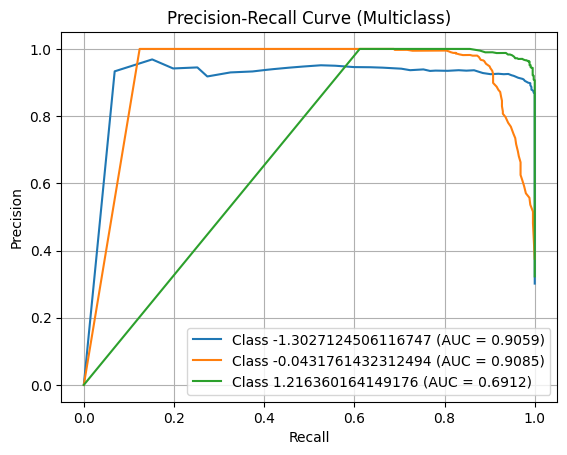

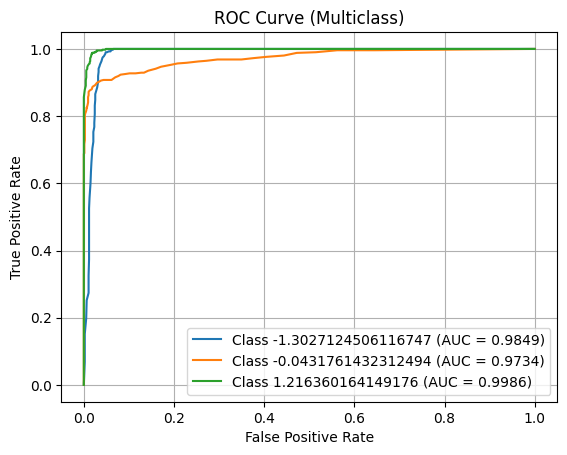

In [11]:
# do the same for LDA
lda = LDA()

lda.fit(X_train, y_train)

y_val_pred_lda = lda.predict(X_val)
y_val_pred_proba_lda = lda.predict_proba(X_val)

accuracy_score = accuracy(y_val, y_val_pred_lda)
precision_score = precision(y_val, y_val_pred_lda)
recall_score = recall(y_val, y_val_pred_lda)
f1_score_value = f1_score(y_val, y_val_pred_lda)

print(f"Accuracy: {accuracy_score:.4f}")
print(f"Precision: {precision_score:.4f}")
print(f"Recall: {recall_score:.4f}")
print(f"F1 Score: {f1_score_value:.4f}")

plot_conf_matrix(y_val, y_val_pred_lda)
_ = plot_pr_curve(y_val, y_val_pred_proba_lda)
_ = plot_roc_curve(y_val, y_val_pred_proba_lda)



In [12]:
# do the same for random forest
rf = RandomForest()

rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)
y_val_pred_proba_rf = rf.predict_proba(X_val)


KeyboardInterrupt: 

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


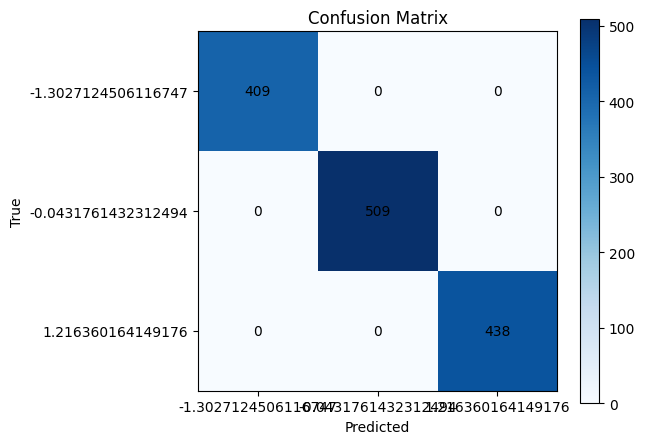

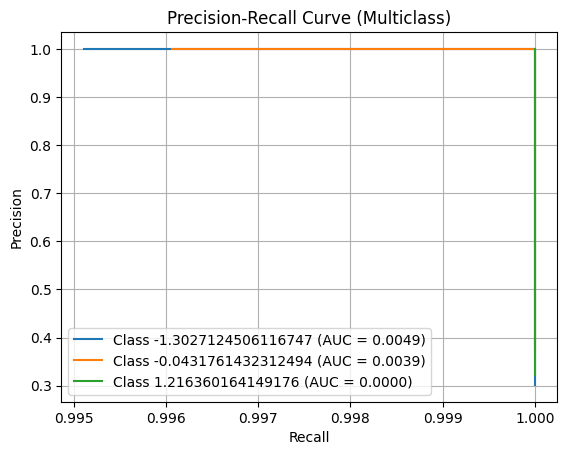

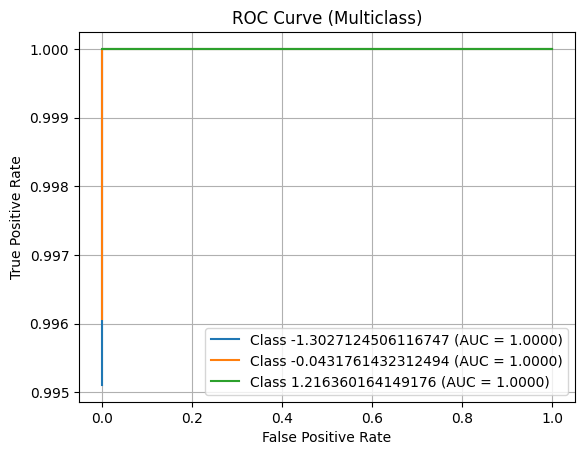

In [ ]:
accuracy_score = accuracy(y_val, y_val_pred_rf)
precision_score = precision(y_val, y_val_pred_rf)
recall_score = recall(y_val, y_val_pred_rf)
f1_score_value = f1_score(y_val, y_val_pred_rf)

print(f"Accuracy: {accuracy_score:.4f}")
print(f"Precision: {precision_score:.4f}")
print(f"Recall: {recall_score:.4f}")
print(f"F1 Score: {f1_score_value:.4f}")

plot_conf_matrix(y_val, y_val_pred_rf)
_ = plot_pr_curve(y_val, y_val_pred_proba_rf)
_ = plot_roc_curve(y_val, y_val_pred_proba_rf)